# Part 1: Clustering Relationship Profiles

This notebook explores the dataset through clustering. The goal is not to discover a single "correct" segmentation, but to build a set of broad, interpretable relationship profiles and describe what each cluster represents.

The emphasis here is on meaning and communication:

- Can respondents be grouped into broad relationship types?
- What characteristics define each type?
- What story does each cluster tell?

This is an exploratory analysis, so the clusters should be interpreted as descriptive groupings rather than natural or fixed categories.

## 1. Setup

We load the data and import the tools needed for preprocessing, clustering, and visualisation.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")

df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta").copy()

/tmp/ipykernel_21413/3193232704.py:12: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta").copy()


## 2. Clustering Strategy

To keep the clusters interpretable, we cluster on **wave 1 relationship profile variables** rather than on later outcomes.

That means the clustering is based on factors such as:

- how the couple met
- age when they met
- relationship duration
- education
- marital status
- same-sex vs different-sex couple type

We then use later outcomes like breakup or still-together status only to **describe** the clusters afterward, not to create them.

## 3. Build the Relationship Features

We recreate broad meeting-context variables and a compact set of profile variables for clustering.

In [20]:
social_cols = [
    "w1_q24_met_through_friend",
    "w1_q24_met_through_family",
    "w1_q24_met_through_as_nghbrs"
]

work_cols = [
    "w1_q24_met_as_through_cowork",
    "w1_q24_customer",
    "w1_q24_work_neighbors",
    "w1_q24_business_trip"
]

internet_cols = [
    "w1_q24_internet_dating",
    "w1_q24_internet_soc_network",
    "w1_q24_internet_other"
]

binary_cols = social_cols + work_cols + internet_cols + ["w1_q24_met_online"]

for col in binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
    )

# Broad meeting pathways used to define the profile space.
df["met_social"] = (df[social_cols].sum(axis=1) > 0).astype(int)
df["met_work"] = (df[work_cols].sum(axis=1) > 0).astype(int)
df["met_online"] = (df[internet_cols].sum(axis=1) > 0).astype(int)

df["w1_ppage_num"] = pd.to_numeric(df["w1_ppage"], errors="coerce")
df["w1_age_when_met"] = pd.to_numeric(df["w1_age_when_met"], errors="coerce")
df["w1_partner_yrsed"] = pd.to_numeric(df["w1_partner_yrsed"], errors="coerce")
df["w1_subject_yrsed"] = pd.to_numeric(df["w1_subject_yrsed"], errors="coerce")

# Relationship duration is approximated using current age minus age when the couple met.
df["relationship_duration"] = df["w1_ppage_num"] - df["w1_age_when_met"]

df["w1_married_num"] = (
    df["w1_married"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

df["same_sex_couple"] = (
    df["w1_same_sex_couple"]
    .astype(str)
    .str.strip()
    .map({
        "same_sex_couple": 1,
        "NOT same-sex souple": 0
    })
)

df["still_together_w3"] = df["w3_breakup_source"].isna().astype(int)

## 4. Select the Clustering Dataset

We use a compact feature set that balances interpretability and coverage. This keeps enough respondents for clustering while still including social, demographic, and relationship-context information.

In [21]:
cluster_features = [
    "w1_age_when_met",
    "relationship_duration",
    "w1_partner_yrsed",
    "w1_subject_yrsed",
    "w1_married_num",
    "same_sex_couple",
    "met_social",
    "met_work",
    "met_online"
]

df_cluster = df[cluster_features].dropna().copy()

# A few impossible or suspicious values can distort clustering, so we keep basic bounds.
df_cluster = df_cluster[df_cluster["w1_age_when_met"] > 0].copy()
df_cluster = df_cluster[df_cluster["relationship_duration"] >= 0].copy()

df_cluster.shape

(3326, 9)

In [22]:
df_cluster.describe().round(2)

,w1_age_when_met,relationship_duration,w1_partner_yrsed,w1_subject_yrsed,w1_married_num,same_sex_couple,met_social,met_work,met_online
count,3326.00,3326.00,3326.00,3326.00,3326.00,3326.00,3326.00,3326.00,3326.00
mean,26.69,22.73,14.03,13.99,0.62,0.09,0.38,0.23,0.10
std,11.76,17.11,2.55,2.51,0.49,0.29,0.49,0.42,0.31
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,18.00,8.00,12.00,12.00,0.00,0.00,0.00,0.00,0.00
50%,23.00,19.00,13.00,13.00,1.00,0.00,0.00,0.00,0.00
75%,32.00,36.00,16.00,16.00,1.00,0.00,1.00,0.00,0.00
max,84.00,78.00,20.00,20.00,1.00,1.00,1.00,1.00,1.00


## 5. Standardize the Features

K-means is sensitive to scale, so we standardize the feature space before clustering.

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

## 6. Compare Candidate Numbers of Clusters

There is no single objectively correct value of `k`, so we compare several choices using both the inertia curve and silhouette score.

The goal is not to maximize a metric at all costs, but to find a solution that is both reasonably separated and substantively interpretable.

In [24]:
k_values = range(2, 7)
results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels)
    })

k_results = pd.DataFrame(results)
k_results

,k,inertia,silhouette
0,2,24884.222077,0.196150
1,3,21766.578147,0.208027
2,4,19145.196510,0.219066
3,5,16996.440779,0.230560
4,6,15289.072206,0.214109


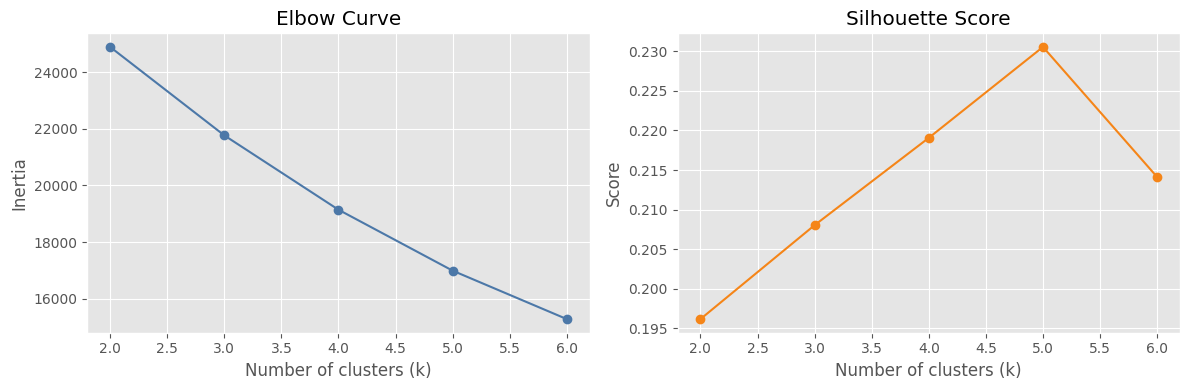

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_results["k"], k_results["inertia"], marker="o", color="#4C78A8")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_results["k"], k_results["silhouette"], marker="o", color="#F58518")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

## 7. Fit the Final Clustering Model

For the main analysis, we use **3 clusters**. This choice is not presented as mathematically final; it is chosen because it usually balances simplicity, separation, and interpretability well in this relationship-profile setting.

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

# Merge the cluster labels back into the main dataset by index.
df["cluster"] = np.nan
df.loc[df_cluster.index, "cluster"] = df_cluster["cluster"]

## 8. Inspect the Raw Cluster Profiles

Before naming the clusters, we compare their average feature values. This is the core step for interpretation.

In [27]:
cluster_profile = df_cluster.groupby("cluster")[cluster_features].mean().round(3)
cluster_profile

,w1_age_when_met,relationship_duration,w1_partner_yrsed,w1_subject_yrsed,w1_married_num,same_sex_couple,met_social,met_work,met_online
cluster,,,,,,,,,
0,34.457001,5.965,14.513,14.569,0.312,0.251,0.090,0.012,1.000
1,30.906000,13.089,13.325,13.442,0.057,0.167,0.373,0.240,0.000
2,23.049000,30.875,14.328,14.175,0.969,0.022,0.440,0.270,0.001


In [28]:
cluster_sizes = df_cluster["cluster"].value_counts().sort_index()
cluster_sizes

cluster
0     346
1    1039
2    1941
Name: count, dtype: int64

## 9. Name the Clusters

The exact labels can be adjusted after reviewing the profile table. These names are meant to be descriptive, not definitive.

In [37]:
cluster_names = {
    0: "Online-initiated relationships",
    1: "Established social relationships",
    2: "Work-centered relationships"
}

df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)
df["cluster_name"] = df["cluster"].map(cluster_names)

df_cluster[["cluster", "cluster_name"]].drop_duplicates().sort_values("cluster")

,cluster,cluster_name
28,0,Online-initiated relationships
0,1,Established social relationships
1,2,Work-centered relationships


## 10. Summarise What Defines Each Cluster

These summaries help translate the cluster centroids into more intuitive stories.

In [38]:
df_cluster.groupby("cluster_name")[cluster_features].mean().round(3)

,w1_age_when_met,relationship_duration,w1_partner_yrsed,w1_subject_yrsed,w1_married_num,same_sex_couple,met_social,met_work,met_online
cluster_name,,,,,,,,,
Established social relationships,30.906000,13.089,13.325,13.442,0.057,0.167,0.373,0.240,0.000
Online-initiated relationships,34.457001,5.965,14.513,14.569,0.312,0.251,0.090,0.012,1.000
Work-centered relationships,23.049000,30.875,14.328,14.175,0.969,0.022,0.440,0.270,0.001


In [39]:
summary_cols = ["met_social", "met_work", "met_online", "w1_married_num", "same_sex_couple", "relationship_duration"]
df_cluster.groupby("cluster_name")[summary_cols].mean().round(3)

,met_social,met_work,met_online,w1_married_num,same_sex_couple,relationship_duration
cluster_name,,,,,,
Established social relationships,0.373,0.240,0.000,0.057,0.167,13.089
Online-initiated relationships,0.090,0.012,1.000,0.312,0.251,5.965
Work-centered relationships,0.440,0.270,0.001,0.969,0.022,30.875


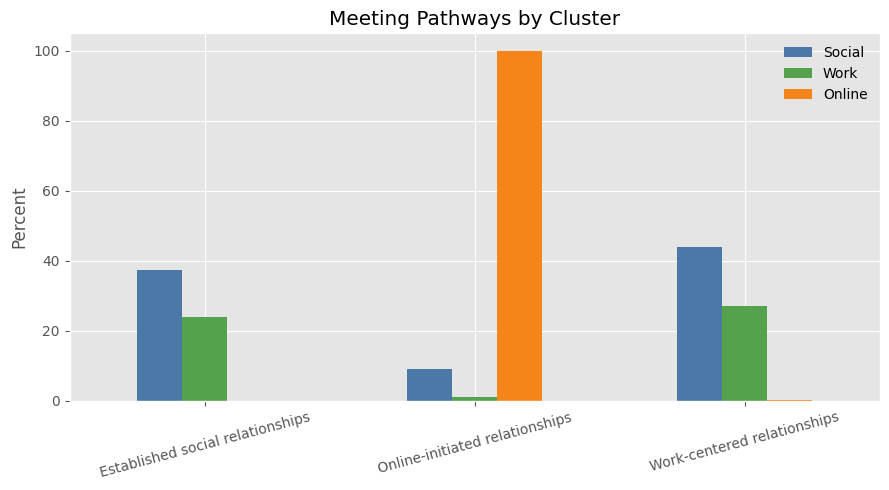

In [41]:
meeting_pathways = (
    df_cluster.groupby("cluster_name")[["met_social", "met_work", "met_online"]]
    .mean()
    .mul(100)
    .rename(columns={
        "met_social": "Social",
        "met_work": "Work",
        "met_online": "Online"
    })
)

ax = meeting_pathways.plot(
    kind="bar",
    figsize=(9, 5),
    color={
        "Social": "#4C78A8",
        "Work": "#54A24B",
        "Online": "#F58518"
    }
)
ax.set_title("Meeting Pathways by Cluster")
ax.set_ylabel("Percent")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 11. Visualise the Clusters in Two Dimensions

A PCA projection helps communicate the cluster structure visually. Because PCA reduces the feature space, this plot is only an approximation of the full clustering geometry.

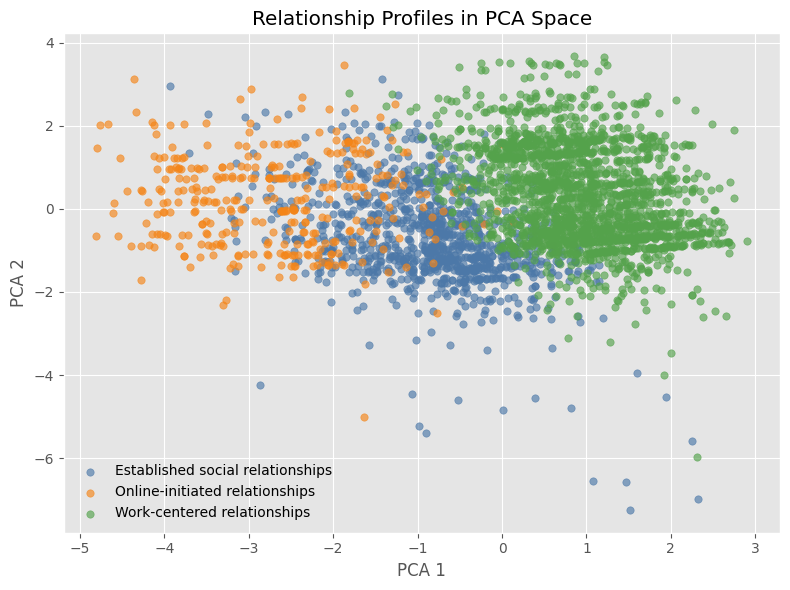

In [42]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PCA 1": X_pca[:, 0],
    "PCA 2": X_pca[:, 1],
    "cluster_name": df_cluster["cluster_name"].values
})

colors = {
    "Established social relationships": "#4C78A8",
    "Online-initiated relationships": "#F58518",
    "Work-centered relationships": "#54A24B"
}

plt.figure(figsize=(8, 6))
for name, group in plot_df.groupby("cluster_name"):
    plt.scatter(group["PCA 1"], group["PCA 2"], label=name, alpha=0.65, s=28, color=colors[name])
plt.title("Relationship Profiles in PCA Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 12. Describe the Clusters with Additional Variables

These variables are not used to create the clusters, but they help us tell a fuller story about the resulting relationship types.

In [43]:
df.groupby("cluster_name")["still_together_w3"].mean().round(3)

cluster_name
Established social relationships    0.959
Online-initiated relationships      0.939
Work-centered relationships         0.978
Name: still_together_w3, dtype: float64

In [35]:
pd.crosstab(df["cluster_name"], df["still_together_w3"], normalize="index").round(3) * 100

still_together_w3,0,1
cluster_name,,
Established social relationships,6.1,93.9
Online-initiated relationships,4.1,95.9
Work-centered relationships,2.2,97.8


In [36]:
df.groupby("cluster_name")["same_sex_couple"].mean().round(3) * 100

cluster_name
Established social relationships    25.1
Online-initiated relationships      16.7
Work-centered relationships          2.2
Name: same_sex_couple, dtype: float64

## 13. Cluster Storylines

After reviewing the profile tables and plots, the clusters can be described in plain language.

A good write-up should connect the statistical grouping back to a social interpretation, for example:

- a cluster with high social-meeting values and longer relationship duration may represent more embedded, established relationships
- a cluster with high online-meeting values may represent digitally initiated relationships that formed through newer social pathways
- a cluster with strong workplace indicators may represent relationships formed through repeated in-person exposure and shared institutional settings

These labels should stay modest and descriptive. They are interpretive summaries, not hard truths about the respondents.

## 14. Conclusion

This clustering exercise suggests that relationship profiles in the dataset can be grouped into a small number of broad types that combine meeting context, relationship timing, and couple characteristics.

The usefulness of the analysis does not come from claiming the clusters are objectively real. It comes from showing that the dataset contains coherent and interpretable relationship patterns, then communicating those patterns honestly.